# 05 — Spatial Integration & Correlation Analysis

Joins tweet sentiment data to NDVI values from Sentinel-2 satellite imagery
using each tweet's geographic coordinates. Runs Pearson correlation to test
whether vegetation density predicts sentiment.

**Inputs:** `data/processed/nyc_sample_with_sentiment.csv`, `nyc_users.csv`,
`data/raw/ndvi/nyc_ndvi_2023.tif`  
**Output:** `data/processed/nyc_spatial_joined.csv`

In [1]:
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.sample import sample_gen
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

## Step 1: Load Sentiment Data

Load the tweet sample with sentiment labels produced in notebook 04.

In [2]:
tweets = pd.read_csv("../data/processed/nyc_sample_with_sentiment.csv")

tweets.head()

,user_id,tweet_id,text,timestamp,clean_text,sentiment_label,sentiment_score,sentiment_numeric
0,23532537,4359057774,Mansion tonite tweeple! DJ Mr Mauricio and a v...,2009-09-24 21:52:48,Mansion tonite tweeple! DJ Mr Mauricio and a v...,positive,0.818303,1
1,31056691,9466378487,RT @HEARTbreakPAM: Watching The Ringer & getti...,2010-02-22 01:12:09,RT @HEARTbreakPAM: Watching The Ringer & getti...,negative,0.898204,-1
2,48388361,6614507963,This is @andrearmani hackin ejaysz twitter!,2009-12-12 18:52:00,This is @andrearmani hackin ejaysz twitter!,neutral,0.738387,0
3,24788891,3988076198,@mrszBreunaXo Wuz good?,2009-09-14 15:39:30,@mrszBreunaXo Wuz good?,neutral,0.780780,0
4,58725560,3808152406,@thaG5 pin:30BC66CE,2009-09-06 19:15:23,@thaG5 pin:30BC66CE,neutral,0.832530,0


## Step 2: Attach Coordinates

Merge tweet sentiment data with user coordinates from `nyc_users.csv` on
`user_id`. Each tweet inherits the home location of the user who posted it.
Note: these are user-reported home coordinates, not real-time tweet locations.

In [3]:
nyc_users = pd.read_csv("../data/processed/nyc_users.csv")

tweets = tweets.merge(
    nyc_users[["user_id", "lat", "lon"]],
    on="user_id",
    how="left"
)

tweets.head()

,user_id,tweet_id,text,timestamp,clean_text,sentiment_label,sentiment_score,sentiment_numeric,lat,lon
0,23532537,4359057774,Mansion tonite tweeple! DJ Mr Mauricio and a v...,2009-09-24 21:52:48,Mansion tonite tweeple! DJ Mr Mauricio and a v...,positive,0.818303,1,40.740790,-73.992447
1,31056691,9466378487,RT @HEARTbreakPAM: Watching The Ringer & getti...,2010-02-22 01:12:09,RT @HEARTbreakPAM: Watching The Ringer & getti...,negative,0.898204,-1,40.665338,-73.740424
2,48388361,6614507963,This is @andrearmani hackin ejaysz twitter!,2009-12-12 18:52:00,This is @andrearmani hackin ejaysz twitter!,neutral,0.738387,0,40.729670,-73.974974
3,24788891,3988076198,@mrszBreunaXo Wuz good?,2009-09-14 15:39:30,@mrszBreunaXo Wuz good?,neutral,0.780780,0,40.668424,-73.948499
4,58725560,3808152406,@thaG5 pin:30BC66CE,2009-09-06 19:15:23,@thaG5 pin:30BC66CE,neutral,0.832530,0,40.812106,-73.956594


## Step 3: Convert to GeoDataFrame

Convert the merged dataframe to a GeoPandas GeoDataFrame using WGS84
coordinate reference system (EPSG:4326) so it can be spatially joined to the
NDVI raster.

In [4]:
gdf = gpd.GeoDataFrame(
    tweets,
    geometry=gpd.points_from_xy(tweets["lon"], tweets["lat"]),
    crs="EPSG:4326"
)

gdf.head()

,user_id,tweet_id,text,timestamp,clean_text,sentiment_label,sentiment_score,sentiment_numeric,lat,lon,geometry
0,23532537,4359057774,Mansion tonite tweeple! DJ Mr Mauricio and a v...,2009-09-24 21:52:48,Mansion tonite tweeple! DJ Mr Mauricio and a v...,positive,0.818303,1,40.740790,-73.992447,POINT (-73.99245 40.74079)
1,31056691,9466378487,RT @HEARTbreakPAM: Watching The Ringer & getti...,2010-02-22 01:12:09,RT @HEARTbreakPAM: Watching The Ringer & getti...,negative,0.898204,-1,40.665338,-73.740424,POINT (-73.74042 40.66534)
2,48388361,6614507963,This is @andrearmani hackin ejaysz twitter!,2009-12-12 18:52:00,This is @andrearmani hackin ejaysz twitter!,neutral,0.738387,0,40.729670,-73.974974,POINT (-73.97497 40.72967)
3,24788891,3988076198,@mrszBreunaXo Wuz good?,2009-09-14 15:39:30,@mrszBreunaXo Wuz good?,neutral,0.780780,0,40.668424,-73.948499,POINT (-73.9485 40.66842)
4,58725560,3808152406,@thaG5 pin:30BC66CE,2009-09-06 19:15:23,@thaG5 pin:30BC66CE,neutral,0.832530,0,40.812106,-73.956594,POINT (-73.95659 40.81211)


## Step 4: Sample NDVI Values

Open the Sentinel-2 derived NDVI raster for NYC and sample the NDVI value at
each tweet's coordinates using `rasterio`. Each tweet is assigned the NDVI
value of the pixel it falls within.

NDVI ranges from -1 to 1:
- Values < 0: water or bare ground
- 0.0 – 0.2: sparse or urban vegetation
- 0.2 – 0.8: moderate to dense vegetation

In [5]:
ndvi_path = "../data/raw/ndvi/nyc_ndvi_2023.tif"

src = rasterio.open(ndvi_path)

In [6]:
coords = [(x,y) for x,y in zip(gdf["lon"], gdf["lat"])]

ndvi_values = [x[0] for x in src.sample(coords)]

gdf["ndvi"] = ndvi_values

gdf.head()

,user_id,tweet_id,text,timestamp,clean_text,sentiment_label,sentiment_score,sentiment_numeric,lat,lon,geometry,ndvi
0,23532537,4359057774,Mansion tonite tweeple! DJ Mr Mauricio and a v...,2009-09-24 21:52:48,Mansion tonite tweeple! DJ Mr Mauricio and a v...,positive,0.818303,1,40.740790,-73.992447,POINT (-73.99245 40.74079),0.089362
1,31056691,9466378487,RT @HEARTbreakPAM: Watching The Ringer & getti...,2010-02-22 01:12:09,RT @HEARTbreakPAM: Watching The Ringer & getti...,negative,0.898204,-1,40.665338,-73.740424,POINT (-73.74042 40.66534),0.643039
2,48388361,6614507963,This is @andrearmani hackin ejaysz twitter!,2009-12-12 18:52:00,This is @andrearmani hackin ejaysz twitter!,neutral,0.738387,0,40.729670,-73.974974,POINT (-73.97497 40.72967),0.186722
3,24788891,3988076198,@mrszBreunaXo Wuz good?,2009-09-14 15:39:30,@mrszBreunaXo Wuz good?,neutral,0.780780,0,40.668424,-73.948499,POINT (-73.9485 40.66842),0.398975
4,58725560,3808152406,@thaG5 pin:30BC66CE,2009-09-06 19:15:23,@thaG5 pin:30BC66CE,neutral,0.832530,0,40.812106,-73.956594,POINT (-73.95659 40.81211),0.043225


## Step 5: Drop Missing Values and Run Correlation

Remove any rows where NDVI or sentiment is null — typically tweets that fell
outside the raster coverage area. Then compute Pearson r between NDVI and
numeric sentiment score.

**Result: r = 0.004, p = 0.594, n = 17,082**

No statistically significant relationship was found, confirming the null
hypothesis. The near-zero correlation suggests vegetation density at a user's
home location does not predict tweet sentiment.

In [7]:
gdf = gdf.dropna(subset=["ndvi", "sentiment_numeric"])

In [8]:
corr, pval = pearsonr(gdf["ndvi"], gdf["sentiment_numeric"])

print("Correlation:", corr)
print("P-value:", pval)

Correlation: 0.004083804674428337
P-value: 0.5935430322550057


## Step 6: Visualize — Raw Scatter

Initial scatter plot of NDVI vs. sentiment. The three horizontal stripes
reflect the discrete nature of sentiment labels (−1, 0, +1) rather than a
data error.

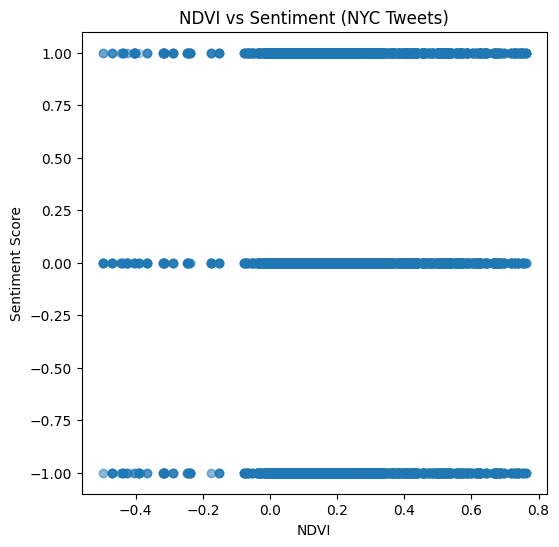

In [9]:
plt.figure(figsize=(6,6))
plt.scatter(gdf["ndvi"], gdf["sentiment_numeric"], alpha=0.3)
plt.xlabel("NDVI")
plt.ylabel("Sentiment Score")
plt.title("NDVI vs Sentiment (NYC Tweets)")
plt.show()

## Step 7: Save Spatial Join Output

Save the spatially joined dataframe for use in visualization notebooks.
Final shape: 17,082 rows after dropping nulls.
- Neutral tweets: 6,968
- Positive tweets: 5,519
- Negative tweets: 4,595

In [10]:
gdf.to_csv("../data/processed/nyc_spatial_joined.csv", index=False)
print("Saved! Shape:", gdf.shape)
print("NDVI range:", gdf['ndvi'].min(), "to", gdf['ndvi'].max())
print("Sentiment counts:", gdf['sentiment_numeric'].value_counts().to_dict())

Saved! Shape: (17082, 12)
NDVI range: -0.49818182 to 0.7612467
Sentiment counts: {0: 6968, 1: 5519, -1: 4595}


## Step 8: Publication-Quality Visualization

Two-panel figure for the research poster:

**Left:** NDVI binned into 20 intervals with mean sentiment per bin plotted
as bubbles. Bubble size encodes tweet count — larger bubbles represent
more data. Regression line confirms near-zero slope.

**Right:** Box plots of NDVI distribution per sentiment class. Nearly
identical medians (negative: 0.123, neutral: 0.117, positive: 0.125)
visually confirm the null result — greenspace density does not differentiate
emotional tone.

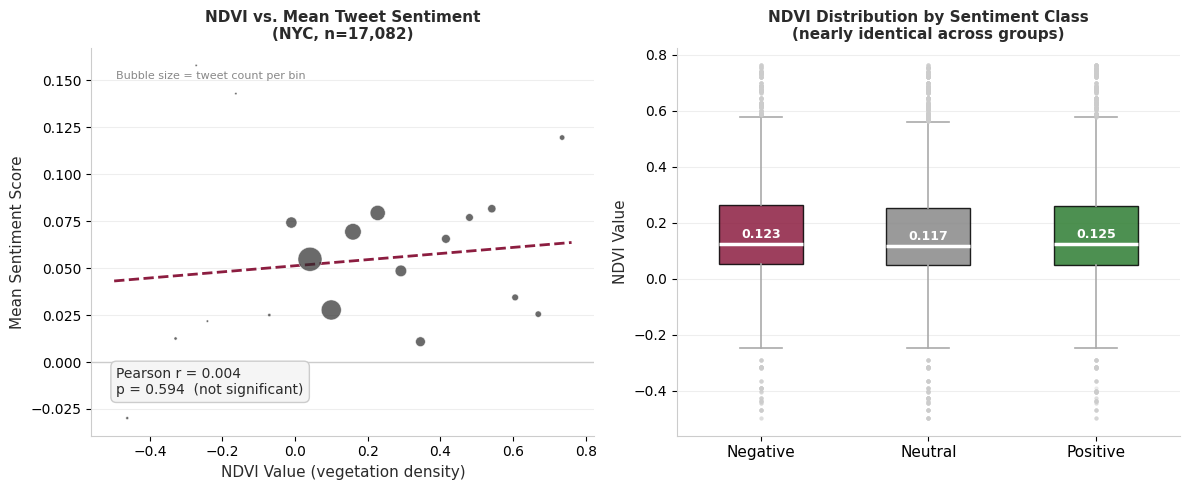

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy import stats

MAROON = '#8C1D40'
GREEN  = '#2E7D32'
GRAY   = '#888888'
DARK   = '#2B2B2B'

clean = gdf.dropna(subset=['ndvi', 'sentiment_numeric'])
r_val, p_val = stats.pearsonr(clean['ndvi'], clean['sentiment_numeric'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('white')

# ── Left: mean sentiment per NDVI bin (much cleaner than raw scatter) ────────
ax = axes[0]
ax.set_facecolor('white')

# Bin NDVI into 20 buckets and plot mean sentiment per bucket
clean['ndvi_bin'] = pd.cut(clean['ndvi'], bins=20)
binned = clean.groupby('ndvi_bin', observed=True).agg(
    mean_sentiment=('sentiment_numeric', 'mean'),
    count=('sentiment_numeric', 'count'),
    ndvi_mid=('ndvi', 'mean')
).dropna()

# Size points by number of tweets in that bin
ax.scatter(binned['ndvi_mid'], binned['mean_sentiment'],
           s=binned['count'] / binned['count'].max() * 300,
           color=DARK, alpha=0.7, edgecolors='white', linewidths=0.5, zorder=3)

# Regression line
m, b  = stats.linregress(clean['ndvi'], clean['sentiment_numeric'])[:2]
xline = np.linspace(clean['ndvi'].min(), clean['ndvi'].max(), 200)
ax.plot(xline, m*xline + b, color=MAROON, linewidth=2,
        linestyle='--', label='Regression line')

ax.axhline(0, color='#CCCCCC', linewidth=1, linestyle='-')
ax.set_xlabel('NDVI Value (vegetation density)', fontsize=11, color=DARK)
ax.set_ylabel('Mean Sentiment Score', fontsize=11, color=DARK)
ax.set_title('NDVI vs. Mean Tweet Sentiment\n(NYC, n=17,082)',
             fontsize=11, fontweight='bold', color=DARK)
ax.text(0.05, 0.10,
        f'Pearson r = {r_val:.3f}\np = {p_val:.3f}  (not significant)',
        transform=ax.transAxes, fontsize=10, color=DARK,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5', edgecolor='#cccccc'))
ax.text(0.05, 0.92, 'Bubble size = tweet count per bin',
        transform=ax.transAxes, fontsize=8, color=GRAY)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#CCCCCC')
ax.yaxis.grid(True, color='#EEEEEE')
ax.set_axisbelow(True)

# ── Right: box plot ──────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('white')

groups = [
    clean[clean['sentiment_label']=='negative']['ndvi'],
    clean[clean['sentiment_label']=='neutral']['ndvi'],
    clean[clean['sentiment_label']=='positive']['ndvi'],
]
bp = ax2.boxplot(groups, patch_artist=True, widths=0.5,
                 medianprops=dict(color='white', linewidth=2.5),
                 flierprops=dict(marker='o', markersize=3,
                                 markerfacecolor='#CCCCCC',
                                 markeredgecolor='none', alpha=0.4))
box_colors = [MAROON, GRAY, GREEN]
for patch, c in zip(bp['boxes'], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.85)
for element in ['whiskers', 'caps']:
    for item in bp[element]:
        item.set_color('#AAAAAA')
        item.set_linewidth(1.2)

# Annotate with median values
medians = [g.median() for g in groups]
for i, med in enumerate(medians):
    ax2.text(i+1, med+0.01, f'{med:.3f}',
             ha='center', va='bottom', fontsize=9,
             fontweight='bold', color='white')

ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(['Negative', 'Neutral', 'Positive'], fontsize=11)
ax2.set_ylabel('NDVI Value', fontsize=11, color=DARK)
ax2.set_title('NDVI Distribution by Sentiment Class\n(nearly identical across groups)',
              fontsize=11, fontweight='bold', color=DARK)
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['left','bottom']].set_color('#CCCCCC')
ax2.yaxis.grid(True, color='#EEEEEE')
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('fig_ndvi_sentiment_correlation.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()